# Implement Regression for Video Game Sales 🎮🕹️

1. About Dataset :
   
Video game sales from North America, Japan, the EU, Africa, and the rest of the world for 64,016 titles released from 1971-2024, including information like critic's score, genre, console, and more.

Link to dataset : https://www.kaggle.com/datasets/siddharth0935/video-game-sales

2. Features :

 - img : URL slug for the box art
 - title : Game title
 - console : Console the game was released for
 - genre : Genre of the game
 - publisher : Publisher of the game
 - developer : Developer of the game
 - critic_score : Metacritic score (out of 10)
 - total_sales : Global sales of copies in millions
 - na_sales : North America sales of copies in millions
 - jp_sales : Japanese sales of copies in millions
 - pal_sales : European & African sales of copies in millions
 - other_sales : Rest of world sales of copies in millions
 - release_date : Date the game was released on
 - last_update : Date the data was last updated

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Read data from csv
data_csv = pd.read_csv(r"C:\Users\stfal\OneDrive\Desktop\MachineLearning\Project-1\Lab1_LinearRegression\dataset\vgchartz-2024.csv")

In [3]:
# Some info about the data
data_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [4]:
# Let's see missing values
data_csv.isna().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

### Fill missing values 

* Fill numerical data

In [5]:
for label , content in data_csv.items() :
    if pd.api.types.is_numeric_dtype(content):
        print(label)

critic_score
total_sales
na_sales
jp_sales
pal_sales
other_sales


In [6]:
# Fill numeric rows with the median 
for label , content in data_csv.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Fill missing numeric values with median 
            data_csv[label] = content.fillna(content.median())

* Fill object data

In [7]:
for label , content in data_csv.items() :
    if pd.api.types.is_object_dtype(content):
        print(label)

img
title
console
genre
publisher
developer
release_date
last_update


In [8]:
for label , content in data_csv.items():
    if pd.api.types.is_object_dtype(content):
        if pd.isnull(content).sum():
            #  Fill missing string values with Unknown
            data_csv[label] = content.fillna("Unknown")

In [9]:
data_csv.isna().sum()

img             0
title           0
console         0
genre           0
publisher       0
developer       0
critic_score    0
total_sales     0
na_sales        0
jp_sales        0
pal_sales       0
other_sales     0
release_date    0
last_update     0
dtype: int64

### Turning categorical variabels into numbers

In [10]:
for label , content in data_csv.items():
    if not pd.api.types.is_numeric_dtype(content):
        data_csv[label] = pd.Categorical(content).codes + 1

In [11]:
data_csv.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,31526,13725,55,1,2446,6367,9.4,20.32,6.37,0.99,9.85,3.12,6006,1546
1,27433,13725,56,1,2446,6367,9.7,19.39,6.06,0.60,9.71,3.02,6356,14
2,6702,13737,54,1,2446,6367,9.6,16.15,8.41,0.47,5.49,1.78,2844,1546
3,42887,13725,74,1,2446,6367,7.5,15.86,9.06,0.06,5.33,1.42,6006,1546
4,25079,5272,56,16,102,7829,8.1,15.09,6.18,0.41,6.05,2.44,6572,25


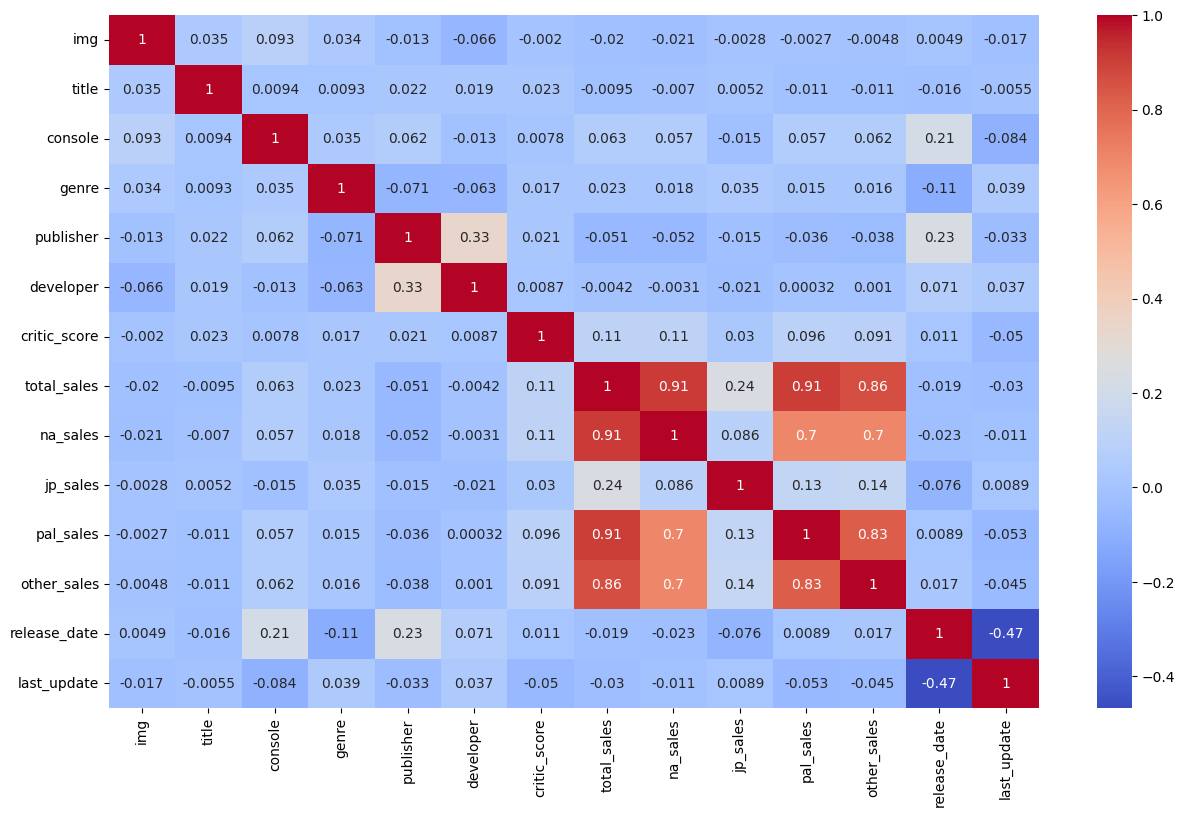

In [12]:
correlation_matrix = data_csv.corr()

plt.figure(figsize=(15,9))
sns.heatmap(correlation_matrix , annot=True , cmap='coolwarm')
plt.show()

In [13]:
# Create X & y variable 
X = data_csv[["pal_sales"]]
y = data_csv["total_sales"]

In [14]:
# Split data in train and valid 
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train) , len(y_train) , len(X_test) , len(y_test) 

(51212, 51212, 12804, 12804)

# Bivariat
## Linear Regression 

In [15]:
from sklearn.linear_model import LinearRegression
import time 

# Model used for predictions
model = LinearRegression()
model.fit(X_train,y_train)
model.score(X_train,y_train)

0.8227665366353004

In [16]:
start_time = time.time()
y_pred = model.predict(X_test)
end_time = time.time()
linear_regression_time = (end_time - start_time) * 1000

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function for model evaluation
def show_scores(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print()
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

In [18]:
linear_regression_score = show_scores(y_test,y_pred)
print(f"Execution time : {linear_regression_time:.4f} ms")
linear_regression_score


Execution time : 1.4846 ms


{'MAE': 0.05739682272636778,
 'MSE': 0.034507416059521824,
 'RMSE': np.float64(0.1857617184985158),
 'R2': 0.8128193533720363}

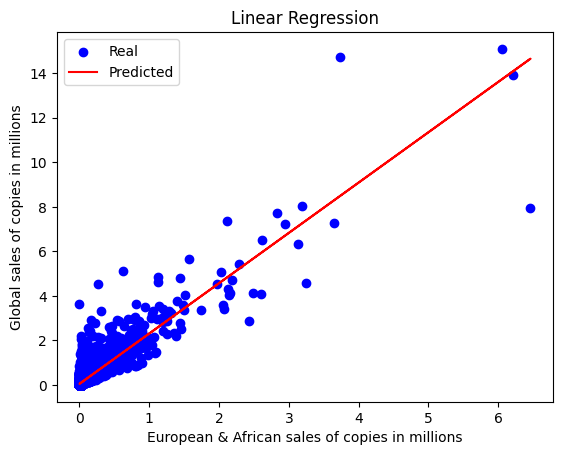

In [19]:
plt.scatter(X_test.iloc[:,0] , y_test , color='blue' , label='Real')
plt.plot(X_test.iloc[:,0] , y_pred , color="red" , label="Predicted")

plt.title('Linear Regression')
plt.xlabel('European & African sales of copies in millions')
plt.ylabel('Global sales of copies in millions')
plt.legend()
plt.show()

## Plynomial Regression

In [20]:
from sklearn.preprocessing import PolynomialFeatures
# Function for Polynomial Regression
def polynomial_feature(degree):
    poly_model_deg = PolynomialFeatures(degree=degree)
    
    X_train_poly = poly_model_deg.fit_transform(X_train)
    X_test_poly = poly_model_deg.transform(X_test)
    
    model.fit(X_train_poly , y_train)
    train_score = model.score(X_train_poly , y_train)
    print(f"Train score : {train_score}")

    x_dense = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1,1)
    x_dense_df = pd.DataFrame(x_dense, columns=X_train.columns)
    x_dense_poly = poly_model_deg.transform(x_dense_df)
    y_dense_pred = model.predict(x_dense_poly)
    
    
    start_time = time.time()
    y_pred_poly = model.predict(X_test_poly)
    end_time = time.time()
    time_sec = (end_time - start_time) * 1000
    print(f"Execution time : {time_sec:.4f} ms")
    score = show_scores(y_test,y_pred_poly)
    print("Predict Score :")
    print(f' MAE : {score['MAE']}\n MSE : {score['MSE']}\n RMSE : {score['RMSE']}\n R2 : {score['R2']}\n')
    print()
    plt.scatter(X_test.iloc[:,0] , y_test , color='blue' , label='Real')
    plt.plot(x_dense , y_dense_pred , color="red" , label="Predicted")
    
    plt.title(f'Polynomial Regression - Degree {degree}')
    plt.xlabel('European & African sales of copies in millions')
    plt.ylabel('Global sales of copies in millions')
    plt.legend()
    plt.show()

    return {"Time" : time_sec , "Score" : score}

* Degree 2 

Train score : 0.8353163972039636
Execution time : 0.0000 ms

Predict Score :
 MAE : 0.053312522502328354
 MSE : 0.0333663916677943
 RMSE : 0.18266469737689958
 R2 : 0.819008680416792




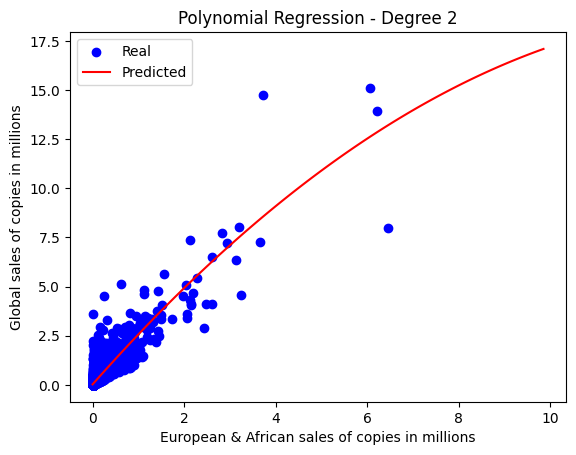

In [21]:
poly2 = polynomial_feature(2)

* Degree 4

Train score : 0.8369562089504969
Execution time : 0.0000 ms

Predict Score :
 MAE : 0.05404064476175602
 MSE : 0.03386299523772916
 RMSE : 0.18401900781639152
 R2 : 0.8163149238869543




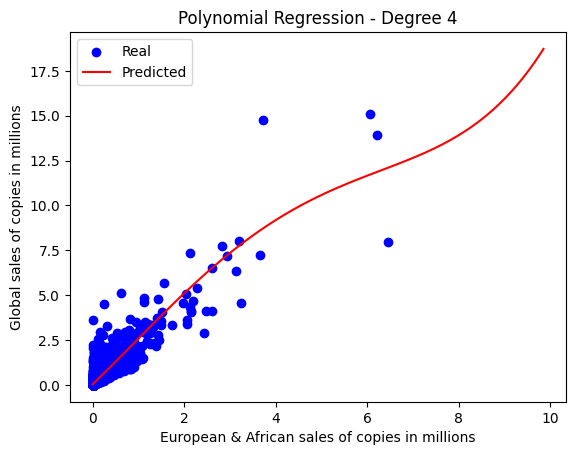

In [22]:
poly4 = polynomial_feature(4)

* Degree 6

Train score : 0.8427354084337461
Execution time : 0.0000 ms

Predict Score :
 MAE : 0.05307694669431418
 MSE : 0.03226260898388183
 RMSE : 0.17961795284403456
 R2 : 0.824995995032152




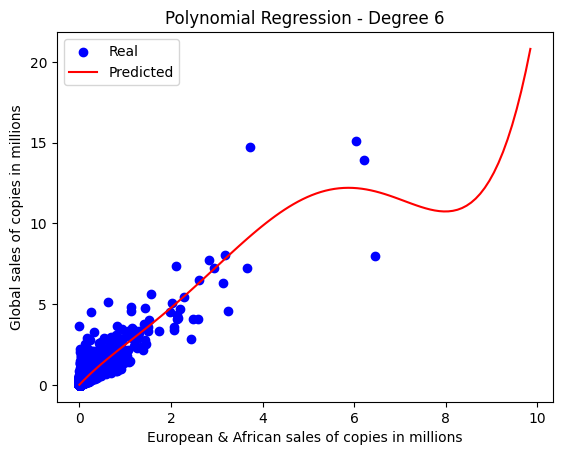

In [23]:
poly6 = polynomial_feature(6)

* Degree 8

Train score : 0.8430003401897114
Execution time : 0.0000 ms

Predict Score :
 MAE : 0.05317543964647636
 MSE : 0.0320988860437988
 RMSE : 0.17916161989611168
 R2 : 0.8258840871958688




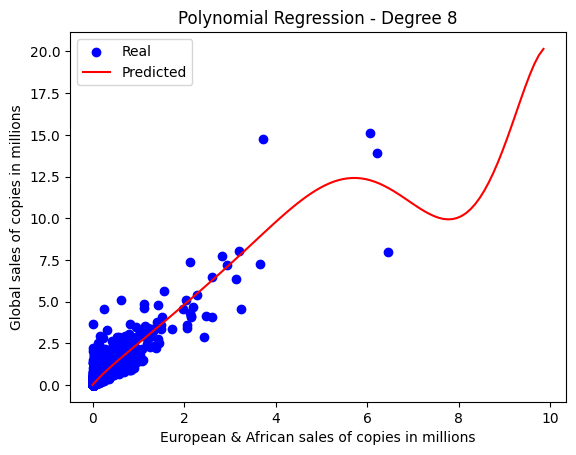

In [24]:
poly8 = polynomial_feature(8)

## Logistic Regression

For Logistic Regression, we need a new feature for classification.
I will create an `is_top` feature that predicts whether the game is in the Top Sales or not.

In [25]:
# If the sales are over 90% it will be in Top 
threshold = data_csv['total_sales'].quantile(0.9)
data_csv['is_top'] = (data_csv["total_sales"] >= threshold).astype(int)

In [26]:
data_csv["is_top"]

0        1
1        1
2        1
3        1
4        1
        ..
64011    0
64012    0
64013    0
64014    0
64015    0
Name: is_top, Length: 64016, dtype: int64

In [27]:
# Set X & y variable
X = data_csv[["total_sales"]]
y = data_csv["is_top"]

# Split data into train and validation 
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train) , len(y_train) , len(X_test) , len(y_test)

(51212, 51212, 12804, 12804)

In [28]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train , y_train)
log_model.score(X_train , y_train)

0.9943177380301492

In [29]:
start_time = time.time()
y_pred_log = log_model.predict(X_test)
end_time = time.time()
log_model_time = (end_time - start_time) * 1000

log_scores = show_scores(y_test , y_pred_log)
print(f"{log_model_time:.4f} ms")
log_scores


0.0000 ms


{'MAE': 0.005857544517338332,
 'MSE': 0.005857544517338332,
 'RMSE': np.float64(0.07653459686532837),
 'R2': 0.9348528456511748}

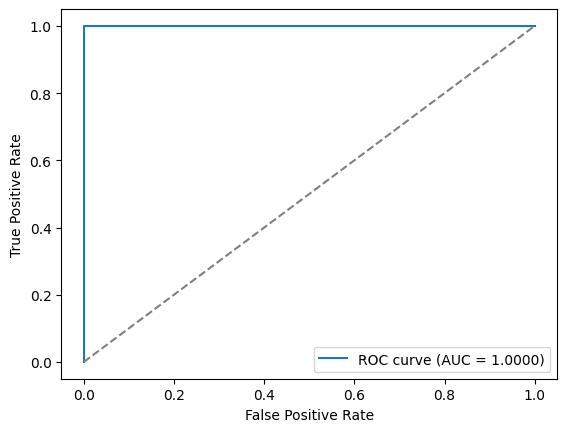

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = log_model.predict_proba(X_test)[:,1]

fpr , tpr , thresholds = roc_curve(y_test,y_prob)

auc = roc_auc_score(y_test , y_prob)

plt.plot(fpr , tpr , label = f"ROC curve (AUC = {auc:.4f})")
plt.plot([0,1] , [0,1] , linestyle='--' , color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

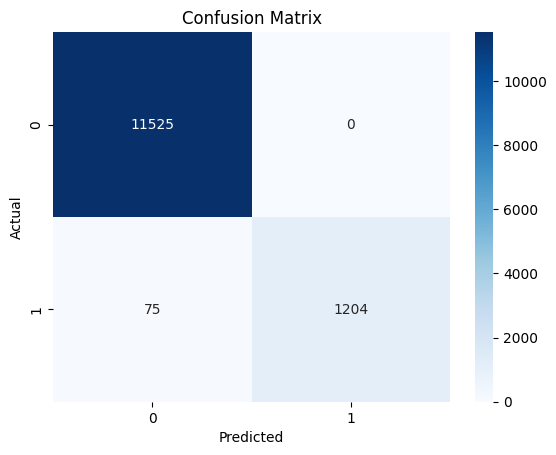

In [31]:
from sklearn.metrics import confusion_matrix

logistic_confusion_matrix = confusion_matrix(y_test , y_pred_log)

sns.heatmap(logistic_confusion_matrix , annot=True , fmt='d' , cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Table with Scores 

In [32]:
results = []

results.append({
    "Model" : "Linear Regression",
    "Mean Absolute Error" : linear_regression_score["MAE"],
    "Mean Squared Error" : linear_regression_score["MSE"],
    "Root Mean Squared Error" : float(linear_regression_score["RMSE"]),
    "R^2 score" : linear_regression_score["R2"],
    "Execution Time (ms)" : linear_regression_time
})

results.append({
    "Model" : "Polynomial Regression Degree 2",
    "Mean Absolute Error" : poly2["Score"]["MAE"],
    "Mean Squared Error" : poly2["Score"]["MSE"],
    "Root Mean Squared Error" : float(poly2["Score"]["RMSE"]),
    "R^2 score" : poly2["Score"]["R2"],
    "Execution Time (ms)" : poly2["Time"]
})

results.append({
    "Model" : "Polynomial Regression Degree 4",
    "Mean Absolute Error" : poly4["Score"]["MAE"],
    "Mean Squared Error" : poly4["Score"]["MSE"],
    "Root Mean Squared Error" : float(poly4["Score"]["RMSE"]),
    "R^2 score" : poly4["Score"]["R2"],
    "Execution Time (ms)" : poly4["Time"]
})

results.append({
    "Model" : "Polynomial Regression Degree 6",
    "Mean Absolute Error" : poly6["Score"]["MAE"],
    "Mean Squared Error" : poly6["Score"]["MSE"],
    "Root Mean Squared Error" : float(poly6["Score"]["RMSE"]),
    "R^2 score" : poly6["Score"]["R2"],
    "Execution Time (ms)" : poly6["Time"]
})

results.append({
    "Model" : "Polynomial Regression Degree 8",
    "Mean Absolute Error" : poly8["Score"]["MAE"],
    "Mean Squared Error" : poly8["Score"]["MSE"],
    "Root Mean Squared Error" : float(poly8["Score"]["RMSE"]),
    "R^2 score" : poly8["Score"]["R2"],
    "Execution Time (ms)" : poly8["Time"]
})

results.append({
    "Model" : "Logistic Regression",
    "Mean Absolute Error" : log_scores["MAE"],
    "Mean Squared Error" : log_scores["MSE"],
    "Root Mean Squared Error" : float(log_scores["RMSE"]),
    "R^2 score" : log_scores["R2"],
    "Execution Time (ms)" : log_model_time
})

def highlight_row(row):
    return ['background-color: yellow' if row.name == 5 else '' for _ in row]

results_table = pd.DataFrame(results)
results_table.style.apply(highlight_row , axis=1).hide(axis="index")

Model,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,R^2 score,Execution Time (ms)
Linear Regression,0.057397,0.034507,0.185762,0.812819,1.484632
Polynomial Regression Degree 2,0.053313,0.033366,0.182665,0.819009,0.000000
Polynomial Regression Degree 4,0.054041,0.033863,0.184019,0.816315,0.000000
Polynomial Regression Degree 6,0.053077,0.032263,0.179618,0.824996,0.000000
Polynomial Regression Degree 8,0.053175,0.032099,0.179162,0.825884,0.000000
Logistic Regression,0.005858,0.005858,0.076535,0.934853,0.000000


# Multivariat 
## Linear Regression

In [33]:
# Create X & y variable 
X = data_csv[["pal_sales" , "na_sales"]]
y = data_csv["total_sales"]

In [34]:
# Split data in train and valid 
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train) , len(y_train) , len(X_test) , len(y_test) 

(51212, 51212, 12804, 12804)

In [35]:
from sklearn.linear_model import LinearRegression
import time 

# Model used for predictions
model = LinearRegression()
model.fit(X_train,y_train)
model.score(X_train,y_train)

0.973024633471064

In [36]:
start_time = time.time()
y_pred = model.predict(X_test)
end_time = time.time()
linear_regression_multivariat_time = (end_time - start_time) * 1000

In [37]:
linear_regression_multivariat_score = show_scores(y_test,y_pred)
print(f"Execution time : {linear_regression_multivariat_time:.4f} ms")
linear_regression_multivariat_score


Execution time : 0.9983 ms


{'MAE': 0.02790917451458485,
 'MSE': 0.00559035125990018,
 'RMSE': np.float64(0.07476865158540831),
 'R2': 0.9696759223611346}

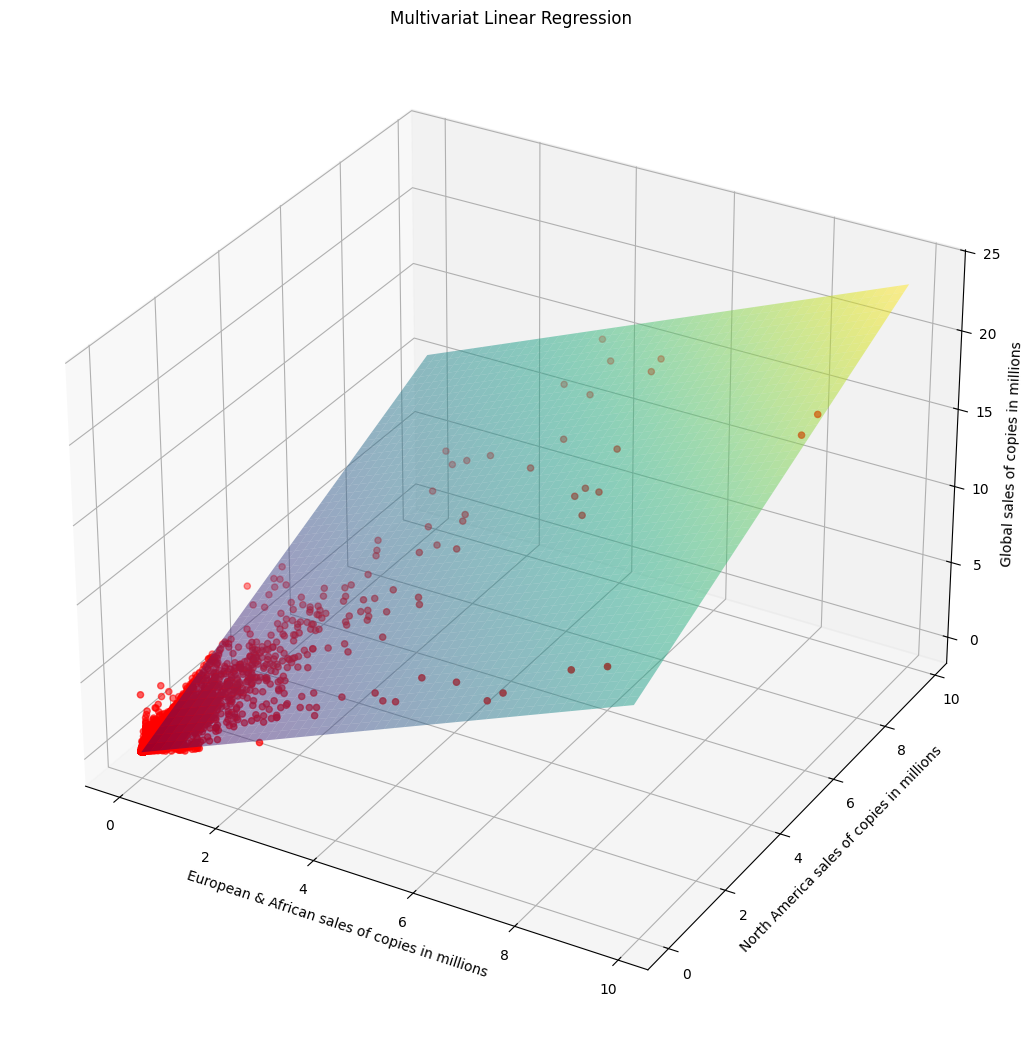

In [38]:
from mpl_toolkits.mplot3d import Axes3D

# Create the plot
fig = plt.figure(figsize=(18,13))
ax = fig.add_subplot(111, projection='3d')

# Define the independent variables
x = data_csv['pal_sales']
y = data_csv['na_sales']
z = data_csv['total_sales']

# Add the data points
ax.scatter(x, y, z, c='red', marker='o')

# Fit a plane using np.linalg.lstsq
A = np.vstack([x, y, np.ones_like(x)]).T
plane_coef, _, _, _ = np.linalg.lstsq(A, z, rcond=None)

# Create a reduced meshgrid for the regression plane
x_range = np.linspace(x.min(), x.max(), 50)
y_range = np.linspace(y.min(), y.max(), 50)
x_plane, y_plane = np.meshgrid(x_range, y_range)

# Calculate the corresponding z values
z_plane = plane_coef[0] * x_plane + plane_coef[1] * y_plane + plane_coef[2]

# Add the regression plane
ax.plot_surface(x_plane, y_plane, z_plane, alpha=0.5, cmap='viridis')

# Add labels and title
ax.set_xlabel('European & African sales of copies in millions')
ax.set_ylabel('North America sales of copies in millions')
ax.set_zlabel('Global sales of copies in millions')
plt.title('Multivariat Linear Regression')

# Show the plot
plt.show()


## Plynomial Regression

In [39]:
# multivariat polynomial feature
def polynomial_multivariat_feature(degree):
    poly_model_deg = PolynomialFeatures(degree=degree)
    
    X_train_poly = poly_model_deg.fit_transform(X_train)
    X_test_poly = poly_model_deg.transform(X_test)
    
    model.fit(X_train_poly , y_train)
    train_score = model.score(X_train_poly , y_train)
    print(f"Train score : {train_score}")

    # Dense grid for 3D plot
    x_range = np.linspace(X_train.iloc[:, 0].min(), X_train.iloc[:, 0].max(), 30)
    y_range = np.linspace(X_train.iloc[:, 1].min(), X_train.iloc[:, 1].max(), 30)
    x_grid, y_grid = np.meshgrid(x_range, y_range)
    
    grid_points = np.c_[x_grid.ravel(), y_grid.ravel()]
    grid_df = pd.DataFrame(grid_points, columns=X_train.columns[:2])
    grid_poly = poly_model_deg.transform(grid_df)
    z_pred = model.predict(grid_poly).reshape(x_grid.shape)

    # Prediction time
    start_time = time.time()
    y_pred_poly = model.predict(X_test_poly)
    end_time = time.time()
    time_sec = (end_time - start_time) * 1000
    print(f"Execution time : {time_sec:.4f} ms")

    score = show_scores(y_test, y_pred_poly)
    print("Predict Score :")
    print(f" MAE : {score['MAE']}\n MSE : {score['MSE']}\n RMSE : {score['RMSE']}\n R2 : {score['R2']}\n")

    # Plot 3D
    fig = plt.figure(figsize=(18, 13))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], y_test, color='blue', label='Real')
    ax.plot_surface(x_grid, y_grid, z_pred, alpha=0.5, cmap='viridis', label='Predicted')

    ax.set_xlabel('European & African sales of copies in millions')
    ax.set_ylabel('North America sales of copies in millions')
    ax.set_zlabel('Global sales of copies in millions')
    plt.title(f'Polynomial Regression 3D - Degree {degree}')
    plt.tight_layout()
    plt.show()

    return {"Time": time_sec, "Score": score}

Train score : 0.9733406646558936
Execution time : 0.0000 ms

Predict Score :
 MAE : 0.027585322760616756
 MSE : 0.005451026592424628
 RMSE : 0.07383106793501383
 R2 : 0.9704316695113796



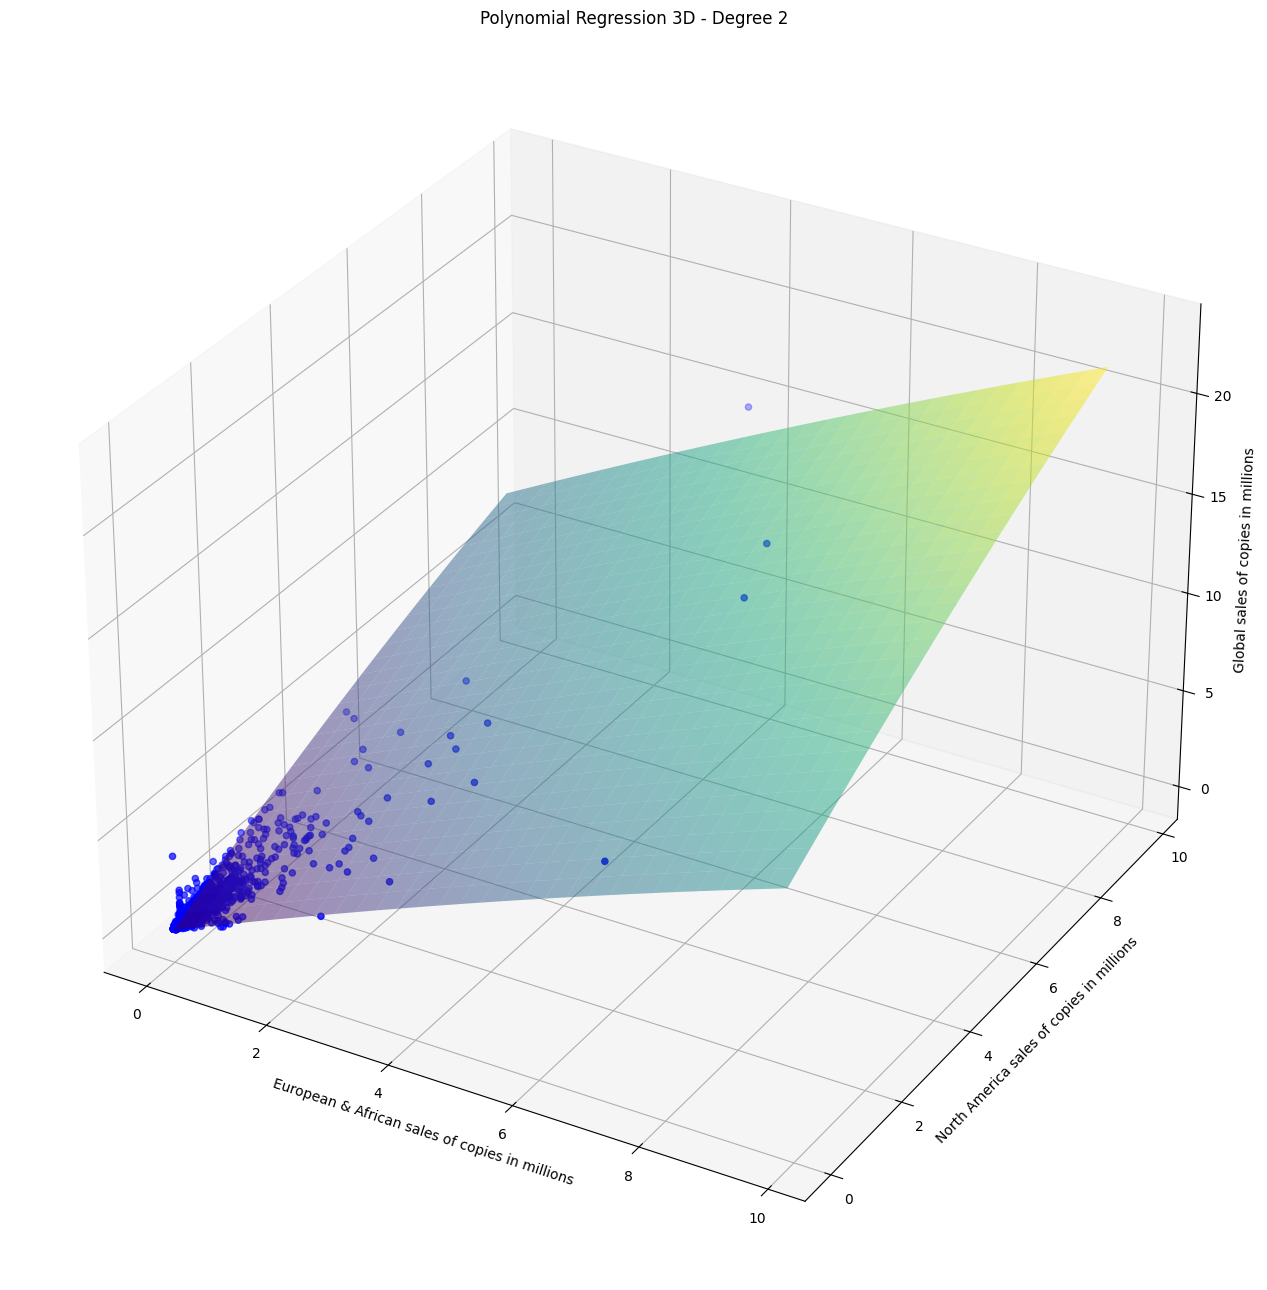

In [40]:
poly2 = polynomial_multivariat_feature(2)

Train score : 0.9739383210241894
Execution time : 0.0000 ms

Predict Score :
 MAE : 0.027054562036244338
 MSE : 0.005511369874344552
 RMSE : 0.07423860097243584
 R2 : 0.9701043458279737



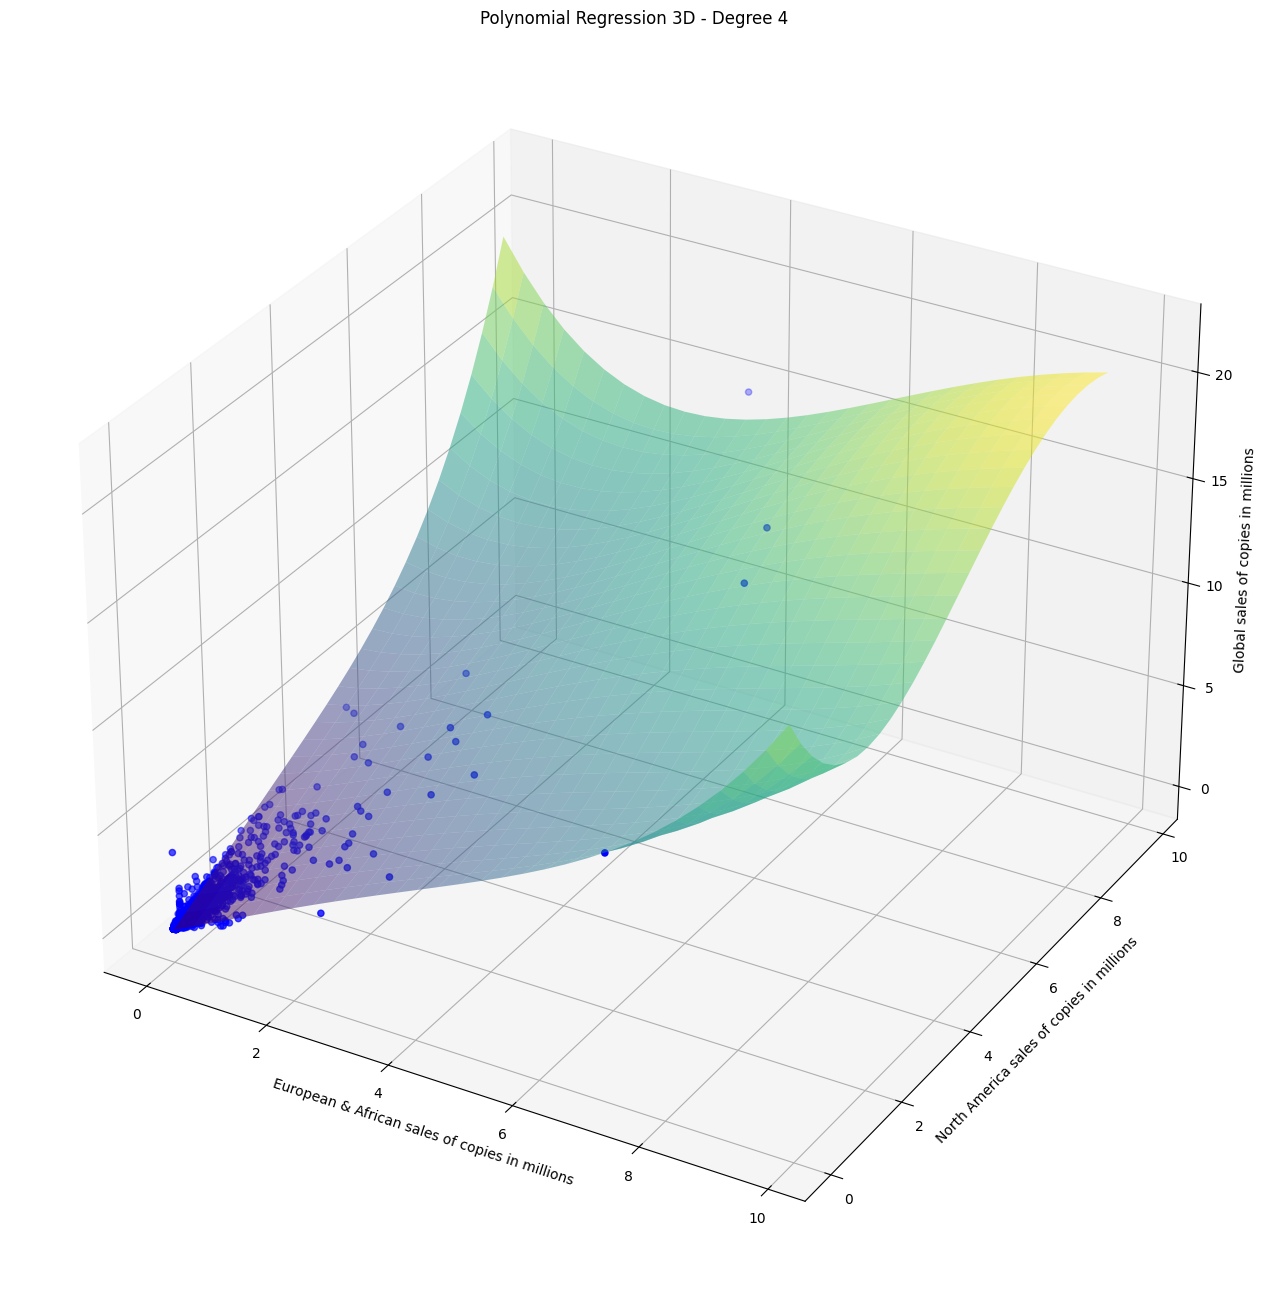

In [41]:
poly4 = polynomial_multivariat_feature(4)

## Logistic Regression

In [42]:
# Set X & y variable
X = data_csv[["total_sales" , "na_sales"]]
y = data_csv["is_top"]

# Split data into train and validation 
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

len(X_train) , len(y_train) , len(X_test) , len(y_test)

(51212, 51212, 12804, 12804)

In [43]:
log_model = LogisticRegression()

log_model.fit(X_train , y_train)
log_model.score(X_train , y_train)

0.9947863781926111

In [44]:
start_time = time.time()
y_pred_log = log_model.predict(X_test)
end_time = time.time()
log_model_time = (end_time - start_time) * 1000

log_scores = show_scores(y_test , y_pred_log)
print(f"{log_model_time:.4f} ms")
log_scores


4.0228 ms


{'MAE': 0.005779443923773821,
 'MSE': 0.005779443923773821,
 'RMSE': np.float64(0.07602265401690354),
 'R2': 0.9357214743758258}

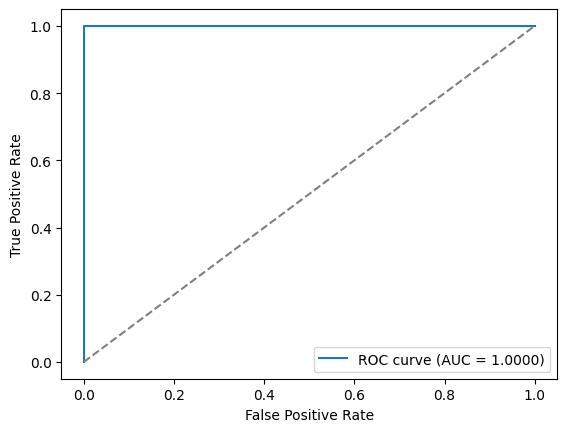

In [45]:
y_prob = log_model.predict_proba(X_test)[:,1]

fpr , tpr , thresholds = roc_curve(y_test,y_prob)

auc = roc_auc_score(y_test , y_prob)

plt.plot(fpr , tpr , label = f"ROC curve (AUC = {auc:.4f})")
plt.plot([0,1] , [0,1] , linestyle='--' , color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

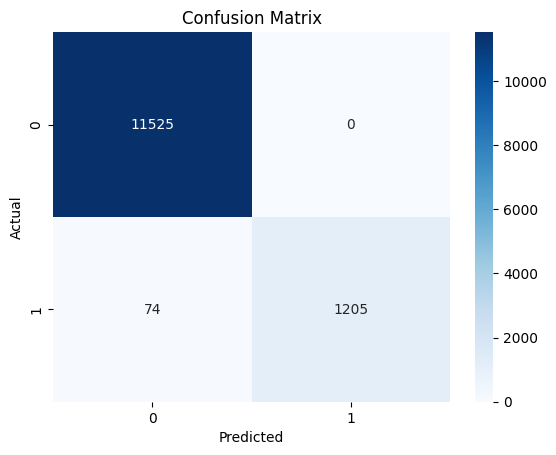

In [46]:
logistic_confusion_matrix = confusion_matrix(y_test , y_pred_log)

sns.heatmap(logistic_confusion_matrix , annot=True , fmt='d' , cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [47]:
results = []

results.append({
    "Model" : "Linear Regression",
    "Mean Absolute Error" : linear_regression_multivariat_score["MAE"],
    "Mean Squared Error" : linear_regression_multivariat_score["MSE"],
    "Root Mean Squared Error" : float(linear_regression_multivariat_score["RMSE"]),
    "R^2 score" : linear_regression_multivariat_score["R2"],
    "Execution Time (ms)" : linear_regression_multivariat_time
})

results.append({
    "Model" : "Polynomial Regression Degree 2",
    "Mean Absolute Error" : poly2["Score"]["MAE"],
    "Mean Squared Error" : poly2["Score"]["MSE"],
    "Root Mean Squared Error" : float(poly2["Score"]["RMSE"]),
    "R^2 score" : poly2["Score"]["R2"],
    "Execution Time (ms)" : poly2["Time"]
})

results.append({
    "Model" : "Polynomial Regression Degree 4",
    "Mean Absolute Error" : poly4["Score"]["MAE"],
    "Mean Squared Error" : poly4["Score"]["MSE"],
    "Root Mean Squared Error" : float(poly4["Score"]["RMSE"]),
    "R^2 score" : poly4["Score"]["R2"],
    "Execution Time (ms)" : poly4["Time"]
})

results.append({
    "Model" : "Logistic Regression",
    "Mean Absolute Error" : log_scores["MAE"],
    "Mean Squared Error" : log_scores["MSE"],
    "Root Mean Squared Error" : float(log_scores["RMSE"]),
    "R^2 score" : log_scores["R2"],
    "Execution Time (ms)" : log_model_time
})

def highlight_row(row):
    return ['background-color: yellow' if row.name == 1 else '' for _ in row]

results_table = pd.DataFrame(results)
results_table.style.apply(highlight_row , axis=1).hide(axis="index")

Model,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,R^2 score,Execution Time (ms)
Linear Regression,0.027909,0.005590,0.074769,0.969676,0.998259
Polynomial Regression Degree 2,0.027585,0.005451,0.073831,0.970432,0.000000
Polynomial Regression Degree 4,0.027055,0.005511,0.074239,0.970104,0.000000
Logistic Regression,0.005779,0.005779,0.076023,0.935721,4.022837
